##### LOF

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt

In [67]:
scaled_features = pd.read_excel(r"Outputs/scaled_features.xlsx")

# original_features.head()
scaled_features

,account_number,mean_call_duration,max_call_duration,unique_contacts_called,unique_destination_codes,unique_numbers_per_account,unique_active_days,days_between_first_and_last_call,active_day_ratio,avg_calls_per_active_day,avg_calls_per_own_number,night_calls_count,day_calls_count,max_calls_to_single_contact,mean_calls_to_single_contact,answered_calls_count,busy_calls_count,no_answer_calls_count,cancelled_calls_count,webrtc_calls_count
0,0000df940049fa1bbefc699a17671295,0.189056,0.418073,1.588235,2.125,0,0.655172,-0.129611,0.463529,0.130939,0.755952,0.000000,0.723032,1.106667,-0.097895,0.939850,0.000,0.000000,0.157895,0
1,000a38dacb7099ae710216b9cd54087c,2.795097,1.116928,-0.117647,0.000,0,0.494253,0.237288,0.014483,-0.599371,0.250000,0.000000,0.227405,0.533333,0.704444,0.315789,0.250,-0.181818,-0.052632,0
2,000b1bddfe23f65af9990f52b3ae004e,-0.201718,-0.491371,-0.411765,-0.375,2,-0.459770,-0.911266,-0.157743,1.152263,-0.458333,0.000000,-0.443149,-0.400000,-0.490000,-0.406015,-0.250,-0.181818,-0.421053,0
3,000d7412614cfc8e6d918ca63e1f37dc,0.623868,0.175296,-0.294118,-0.250,0,-0.436782,-0.556331,-0.546958,2.263374,-0.375000,0.000000,-0.384840,-0.360000,-0.373333,-0.345865,0.000,-0.181818,-0.368421,0
4,0013a4303bdffc2658cd40f80227a524,-0.207689,0.331976,1.705882,1.000,0,3.563218,0.436690,1.680298,1.104915,5.726190,44.666667,4.810496,9.413333,1.962500,4.932331,12.375,2.545455,9.631579,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9598,fff3d1a7b92ca72dbca37b0ba062af95,1.112639,0.867171,-0.529412,-0.625,0,0.126437,0.227318,-0.228444,-0.524885,0.000000,0.000000,-0.017493,0.453333,3.310000,0.030075,-0.250,0.909091,-0.315789,0
9599,fff65074634a70efc96bc738e7bf368c,0.613524,-0.165212,0.294118,0.125,0,0.218391,0.061815,-0.088785,-0.596371,0.047619,0.000000,0.029155,0.066667,-0.096250,0.127820,-0.250,-0.181818,-0.157895,0
9600,fff8217ecefc2d900e361d22d6e90ce0,0.621712,1.116928,2.058824,1.750,0,2.367816,0.492522,0.931453,1.049217,3.821429,5.333333,3.632653,6.746667,0.927391,3.894737,9.125,0.181818,2.526316,0
9601,fff86cfbdc7d0f8b59b65db318798076,-0.639242,-0.236572,-0.117647,0.375,0,0.908046,-0.253240,0.948356,-0.454716,0.648810,0.333333,0.612245,1.413333,1.448889,0.729323,-0.250,-0.181818,0.578947,0


In [ ]:
# 3. Modeliui paliekami tik skaitiniai požymiai
X = scaled_features.drop(columns=['account_number', ], errors="ignore")

# 4. LOF parametrai
# n_neighbors dažnai pradedamas nuo 20, kaip rekomenduojama scikit-learn dokumentacijoje
# contamination – tikėtina anomalijų dalis, pvz. 0.05 = 5 %
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.01,
    metric="manhattan"
)

# 5. Modelio pritaikymas
labels = lof.fit_predict(X)

# LOF balai
# sklearn negative_outlier_factor_: kuo reikšmė mažesnė, tuo objektas labiau išskirtinis
lof_scores_raw = lof.negative_outlier_factor_

# Patogesnis įtartinumo balas: kuo didesnis, tuo labiau įtartinas
lof_anomaly_score = -lof_scores_raw

# Sudarome rezultatų lentelę
lof_results = pd.DataFrame({
    "account_number": scaled_features["account_number"],
    "lof_label": labels,
    "lof_is_anomaly": labels == -1,
    "lof_score": lof_anomaly_score
})

# Rikiuojame nuo labiausiai įtartinų
lof_results = lof_results.sort_values(by="lof_score", ascending=False)

# Išvedame pirmus rezultatus
print(lof_results.head(20))

# Patikriname, kiek vartotojų pažymėta anomalijomis
anomaly_count = lof_results["lof_is_anomaly"].sum()
total_count = len(lof_results)
anomaly_percent = anomaly_count / total_count * 100

print("Bendras vartotojų skaičius:", total_count)
print("LOF pažymėtų įtartinų vartotojų skaičius:", anomaly_count)
print(f"Įtartinų vartotojų dalis: {anomaly_percent:.2f}%")

# 7. Rezultatų išsaugojimas
lof_results.to_excel(r"Outputs/lof_results.xlsx",index=False)


C:\Users\sakal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


                        account_number  lof_label  lof_is_anomaly  \
2049  38409b3e16d916bbd96dbb7395a3aa72         -1            True   
3426  5ab264a61e965acc27e0f3ff90b8e4f3         -1            True   
7896  d28aacaa6253a2bdb63f92464126a8c8         -1            True   
4971  84e7d8b4bec578140a771b88fe6fbf50         -1            True   
5413  913b0822948173940ff6b11eb998dbaa         -1            True   
1647  2c8cff0439be4b658554998c3cd29785         -1            True   
8015  d559beeabd10eee3378767e6e86b7324         -1            True   
1870  333f2aae9cd2d0e02bfc421f22791fd0         -1            True   
6755  b44f4cf454cc2a738123be71c5c25bc7         -1            True   
6527  aef31d257c4ccf6e0543149debc48e8e         -1            True   
1262  22ad383e1e564884a0a6c3f653210ede         -1            True   
8069  d7762a4c8f9e8db9c76adaef8781d1c1         -1            True   
4834  8066bef9196f6e502f3d5aadd7c65f05         -1            True   
2587  461290100f21ca2b1af653cc0377

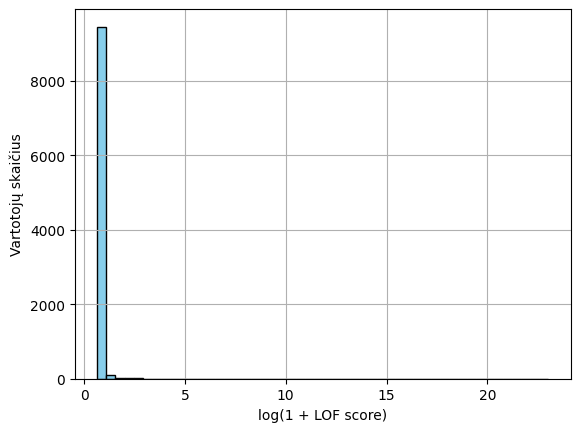

In [69]:
lof_results["lof_score_log"] = np.log1p(lof_results["lof_score"])

plt.hist(lof_results["lof_score_log"], bins=50, color="skyblue", edgecolor="black")
plt.grid(True)
plt.xlabel("log(1 + LOF score)")
plt.ylabel("Vartotojų skaičius")
# plt.title("LOF įverčių pasiskirstymas (log skalėje)")
plt.show()

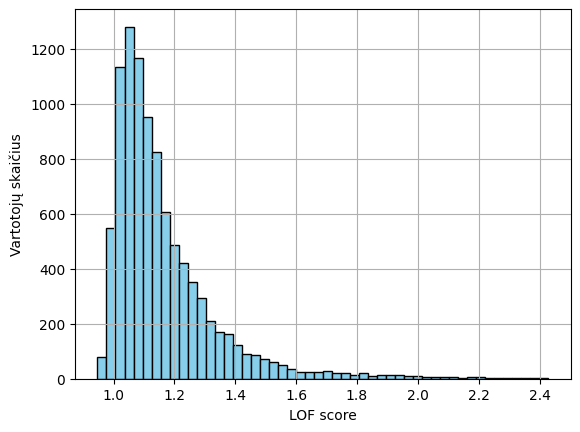

In [70]:
threshold = lof_results["lof_score"].quantile(0.99)
filtered = lof_results[lof_results["lof_score"] <= threshold]

plt.hist(filtered["lof_score"], bins=50, color="skyblue", edgecolor="black")
plt.xlabel("LOF score")
plt.ylabel("Vartotojų skaičius")
# plt.title("LOF įverčių pasiskirstymas (be ekstremalių reikšmių)")
plt.grid(True)
plt.show()

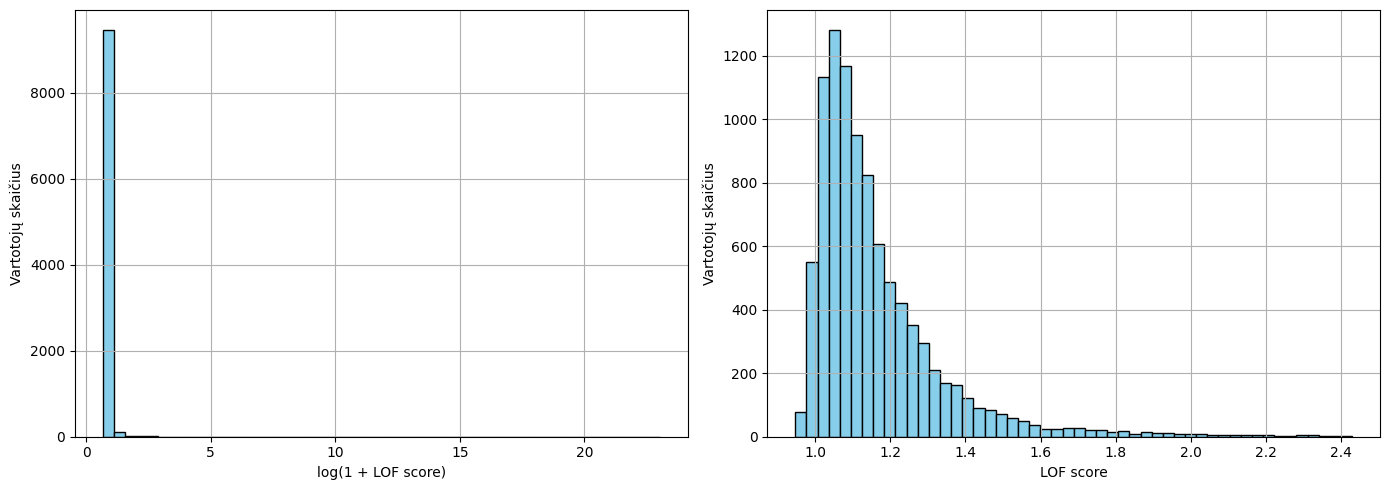

In [ ]:
# LOF įverčių pasiskirstymas

lof_results["lof_score_log"] = np.log1p(lof_results["lof_score"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(lof_results["lof_score_log"], bins=50, color="skyblue", edgecolor="black")
axes[0].grid(True)
axes[0].set_xlabel("log(1 + LOF score)")
axes[0].set_ylabel("Vartotojų skaičius")
# axes[0].set_title("LOF įverčių pasiskirstymas (log skalėje)")

threshold = lof_results["lof_score"].quantile(0.99)
filtered = lof_results[lof_results["lof_score"] <= threshold]

axes[1].hist(filtered["lof_score"], bins=50, color="skyblue", edgecolor="black")
axes[1].grid(True)
axes[1].set_xlabel("LOF score")
axes[1].set_ylabel("Vartotojų skaičius")
# axes[1].set_title("LOF įverčių pasiskirstymas (be ekstremalių reikšmių)")

plt.tight_layout()
plt.show()

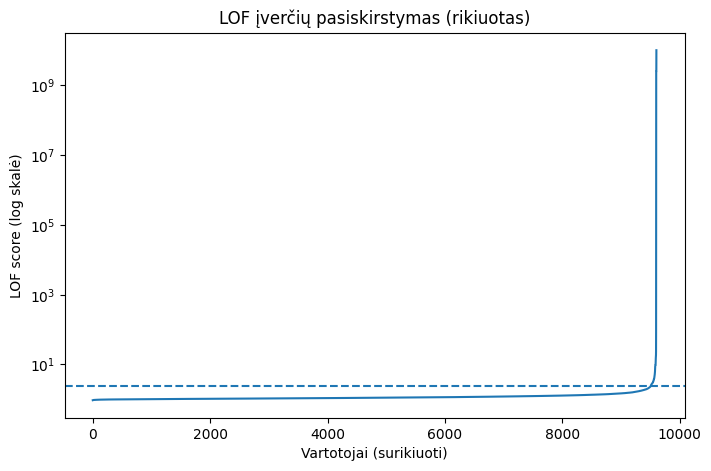

In [72]:
sorted_scores = np.sort(lof_results["lof_score"].values)

plt.figure(figsize=(8,5))
plt.plot(sorted_scores)
plt.yscale("log")

plt.axhline(threshold, linestyle="--")

plt.xlabel("Vartotojai (surikiuoti)")
plt.ylabel("LOF score (log skalė)")
plt.title("LOF įverčių pasiskirstymas (rikiuotas)")

plt.show()
